# QSS 20 Final Project — Visualizations

**Author:** Taj Horowitz
**Updated:** May 2026

**Prerequisite:** Run `01_data_pull.ipynb` first to generate `data/merged_panel.csv`.

## Figures
1. State wealth vs. free-lunch score gap — `sns.regplot` with CI band
2. Gender score trajectories over time — male vs. female by grade
3. Score gaps across all demographic variables — the "through line"
4. OLS regression coefficient plot — which ACS variables predict NAEP scores?

## 1. Setup

In [20]:
# Install adjustText for non-overlapping state labels (only needed once)
try:
    from adjustText import adjust_text
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "adjustText", "-q"])
    from adjustText import adjust_text

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# Load the merged panel saved by 01_data_pull.ipynb
merged = pd.read_csv("data/merged_panel.csv")
print("Loaded merged panel:", merged.shape)
merged.head(3)

Loaded merged panel: (400, 78)


,state_abbrev,grade,year,gender_female,gender_male,pared_did_not_finish_high_school,pared_graduated_college,pared_graduated_high_school,pared_some_education_after_high_school,pared_unknown,...,pov_ratio_50_74,pov_ratio_500_and_over,pov_ratio_75_99,pov_ratio_under_50,state,educ_less_than_hs,educ_hs_or_ged,educ_some_college,educ_bachelors,educ_graduate
0,AK,4,2013,235.67,236.55,NaN,NaN,NaN,NaN,NaN,...,0.018044,0.405049,0.02344,0.027001,Alaska,0.083634,0.273077,0.368287,0.177079,0.097924
1,AK,4,2015,234.67,237.93,NaN,NaN,NaN,NaN,NaN,...,0.018044,0.405049,0.02344,0.027001,Alaska,0.083634,0.273077,0.368287,0.177079,0.097924
2,AK,4,2017,230.46,230.45,NaN,NaN,NaN,NaN,NaN,...,0.018044,0.405049,0.02344,0.027001,Alaska,0.083634,0.273077,0.368287,0.177079,0.097924


## Figure 1 — Score Gaps Across All Demographic Variables

The "through line" figure: every demographic variable you pulled shows a score gap that maps onto socioeconomic disadvantage. Bars show the gap between the advantaged and disadvantaged group for each variable, broken out by grade 4 vs grade 8. The `*` on Parental Education indicates grade 8 only.

PARED columns: ['pared_did_not_finish_high_school', 'pared_graduated_college', 'pared_graduated_high_school', 'pared_some_education_after_high_school', 'pared_unknown']
SRACE10 columns: ['srace10_american_indian_alaska_native', 'srace10_asian', 'srace10_black', 'srace10_hispanic', 'srace10_native_hawaiian_other_pacific_islander', 'srace10_two_or_more_races', 'srace10_white']
Non-white average from: ['srace10_american_indian_alaska_native', 'srace10_asian', 'srace10_black', 'srace10_hispanic', 'srace10_native_hawaiian_other_pacific_islander', 'srace10_two_or_more_races']

PARED gap: pared_graduated_college − pared_did_not_finish_high_school  (grade 8 only)


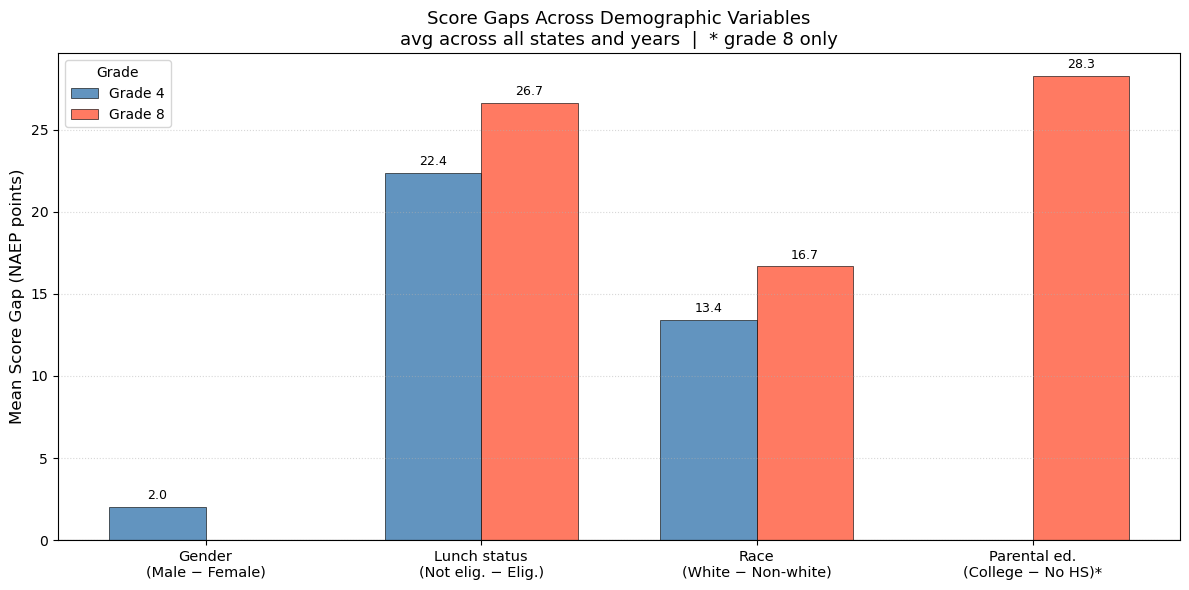

In [21]:
# Print PARED and race column names to confirm what the pivot produced.
# The NAEP category labels get lowercased and space-replaced during pivoting,
# so "Graduated college" becomes "pared_graduated_college"
pared_cols = sorted([c for c in merged.columns if c.startswith('pared_')])
srace_cols  = sorted([c for c in merged.columns if c.startswith('srace10_')])
print("PARED columns:", pared_cols)
print("SRACE10 columns:", srace_cols)

# Partial keyword search so the code doesn't break if NAEP slightly changes a category label.
def find_col(df, *keywords):
    for kw in keywords:
        matches = [c for c in df.columns if kw.lower() in c.lower()]
        if matches:
            return matches[0]
    return None

# Each tuple holds: display label, advantaged column, disadvantaged column, and which grades to include.
# grades=None means both 4 and 8; grades=[8] restricts to grade 8 only.
GAP_PAIRS = []

if 'gender_male' in merged.columns and 'gender_female' in merged.columns:
    GAP_PAIRS.append(('Gender\n(Male − Female)',
                      'gender_male', 'gender_female', None))

lunch_adv = find_col(merged, 'slunch3_not')
lunch_dis = find_col(merged, 'slunch3_elig')
if lunch_adv and lunch_dis:
    GAP_PAIRS.append(('Lunch status\n(Not elig. − Elig.)',
                      lunch_adv, lunch_dis, None))

# Compare White students to the average of all non-white subgroups.
# Note: Asian/Pacific Islander students score above White students nationally on NAEP math,
# so this composite slightly understates the gap relative to a White vs. Black or
# White vs. Hispanic comparison. Treated here as a known limitation.
race_white    = find_col(merged, 'srace10_white')
nonwhite_cols = [c for c in merged.columns
                 if c.startswith('srace10_') and 'white' not in c.lower()]
if race_white and nonwhite_cols:
    merged['srace10_nonwhite_avg'] = merged[nonwhite_cols].mean(axis=1)
    GAP_PAIRS.append(('Race\n(White − Non-white)',
                      race_white, 'srace10_nonwhite_avg', None))
    print(f"Non-white average from: {nonwhite_cols}")

# PARED is grade 8 only — 4th graders don't report parental education.
pared_high = find_col(merged, 'pared_graduated_college', 'pared_college')
pared_low  = find_col(merged, 'pared_did_not', 'pared_no_hs', 'pared_not_finish')
if pared_high and pared_low:
    GAP_PAIRS.append(('Parental ed.\n(College − No HS)*',
                      pared_high, pared_low, [8]))
    print(f"\nPARED gap: {pared_high} − {pared_low}  (grade 8 only)")
else:
    print("\nPARED columns not matched — available:", pared_cols)

records = []
for label, adv, dis, grades in GAP_PAIRS:
    for grade in ([4, 8] if grades is None else grades):
        sub = merged[merged['grade'] == grade]
        gap = (sub[adv] - sub[dis]).mean()
        records.append({'variable': label, 'grade': grade, 'gap': gap})

gap_summary = pd.DataFrame(records)

variables = [p[0] for p in GAP_PAIRS]
x         = np.arange(len(variables))
bar_width = 0.35
colors    = {4: 'steelblue', 8: 'tomato'}

fig, ax = plt.subplots(figsize=(12, 6))

for i, grade in enumerate([4, 8]):
    vals = []
    for v in variables:
        row = gap_summary[(gap_summary['variable'] == v) & (gap_summary['grade'] == grade)]
        vals.append(row['gap'].values[0] if len(row) else np.nan)

    if all(np.isnan(v) for v in vals):
        continue

    bars = ax.bar(x + i * bar_width, vals, bar_width,
                  label=f'Grade {grade}', color=colors[grade], alpha=0.85,
                  edgecolor='k', linewidth=0.5)

    for bar, val in zip(bars, vals):
        if not np.isnan(val) and val > 0.5:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(variables, fontsize=10.5)
ax.set_ylabel('Mean Score Gap (NAEP points)', fontsize=12)
ax.set_title('Score Gaps Across Demographic Variables\n'
             'avg across all states and years  |  * grade 8 only', fontsize=13)
ax.legend(title='Grade', fontsize=10)
ax.yaxis.grid(True, linestyle=':', alpha=0.5)
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Figure 2 — State Wealth vs. Free-Lunch Score Gap

Scatter of median household income vs. the average NAEP score gap between non-eligible and eligible free-lunch students. Built with `sns.regplot` — the shaded band is a 95% confidence interval around the regression line.

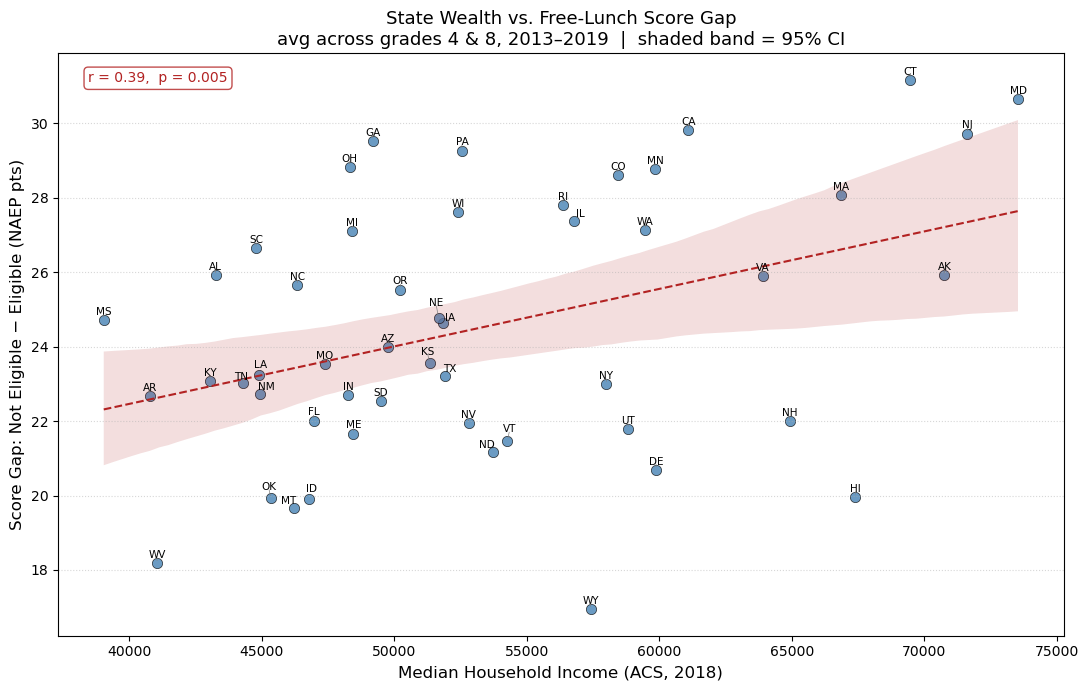

In [22]:
gap_df = merged.copy()
gap_df['score_gap'] = gap_df['slunch3_not_eligible'] - gap_df['slunch3_eligible']

# Collapse to one row per state by averaging the gap across all grade/year combos.
# .first() on median_income just picks the first non-null value — it's the same
# for every row since ACS is a single snapshot.
state_avg = (
    gap_df.groupby('state_abbrev')
    .agg(score_gap=('score_gap', 'mean'),
         median_income=('median_household_income', 'first'))
    .dropna()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 7))

# sns.regplot draws the scatter, fits a linear regression, and shades a 95% CI band —
# all in one call. The CI band is wider at the extremes of income because there are
# fewer states there, so the model is less certain about the true relationship.
sns.regplot(
    data=state_avg,
    x='median_income', y='score_gap',
    ax=ax,
    ci=95,
    scatter_kws=dict(s=55, alpha=0.8, edgecolors='k', linewidths=0.5, color='steelblue'),
    line_kws=dict(color='firebrick', linewidth=1.5, linestyle='--')
)

# adjust_text() nudges labels iteratively until none overlap each other or the data points.
texts = []
for _, row in state_avg.iterrows():
    t = ax.text(row['median_income'], row['score_gap'], row['state_abbrev'],
                fontsize=7.5, ha='center', va='bottom')
    texts.append(t)

adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
            expand_points=(1.3, 1.4))

# Pearson r measures the strength and direction of the linear relationship (-1 to 1).
# The p-value tests whether the correlation is statistically distinguishable from zero.
r, p = stats.pearsonr(state_avg['median_income'], state_avg['score_gap'])
p_str = f"p = {p:.3f}" if p >= 0.001 else "p < 0.001"
ax.annotate(f"r = {r:.2f},  {p_str}", xy=(0.03, 0.95), xycoords='axes fraction',
            fontsize=10, color='firebrick',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='firebrick', alpha=0.8))

ax.set_xlabel('Median Household Income (ACS, 2018)', fontsize=12)
ax.set_ylabel('Score Gap: Not Eligible − Eligible (NAEP pts)', fontsize=12)
ax.set_title('State Wealth vs. Free-Lunch Score Gap\n'
             'avg across grades 4 & 8, 2013–2019  |  shaded band = 95% CI', fontsize=13)
ax.yaxis.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Figure 3 — Gender Math Gap Over Time

Average male − female NAEP math score by year, with separate lines for grade 4 and grade 8. This is the starting point for the gender analysis — showing the *size* of the gap directly across years.

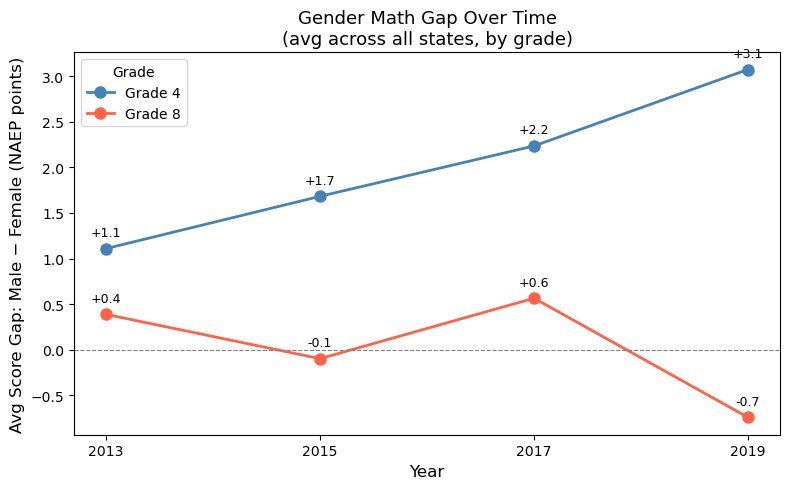

In [23]:
# Compute average male minus female score for each year and grade combination,
# averaged across all states. This gives the national-level gap trajectory.
gender_gap_df = (
    merged.assign(gender_gap=merged['gender_male'] - merged['gender_female'])
          .groupby(['year', 'grade'])['gender_gap']
          .mean()
          .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

for grade, color in [(4, 'steelblue'), (8, 'tomato')]:
    sub = gender_gap_df[gender_gap_df['grade'] == grade]
    ax.plot(sub['year'], sub['gender_gap'],
            marker='o', linewidth=2, markersize=8,
            label='Grade ' + str(grade), color=color)
    for _, row in sub.iterrows():
        ax.annotate(f"{row['gender_gap']:+.1f}",
                    (row['year'], row['gender_gap']),
                    textcoords='offset points', xytext=(0, 9),
                    ha='center', fontsize=9)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks([2013, 2015, 2017, 2019])
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Avg Score Gap: Male − Female (NAEP points)', fontsize=12)
ax.set_title('Gender Math Gap Over Time\n(avg across all states, by grade)', fontsize=13)
ax.legend(title='Grade', loc='best')
plt.tight_layout()
plt.show()

## Figure 4 — Male vs. Female Score Trajectories Over Time

Instead of just the gap, this shows the actual male and female score trajectories separately — 4 lines total, each with a linear trend line. Shows whether male scores are falling, female scores are rising, or both.

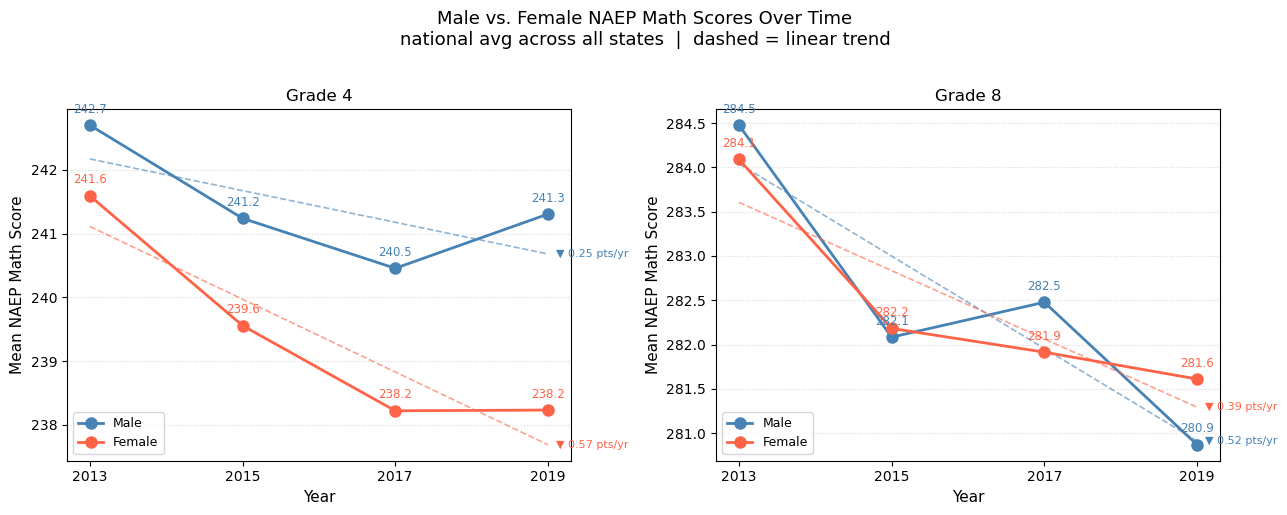

In [24]:
gender_df = (
    merged.groupby(['year', 'grade'])
    .agg(male=('gender_male', 'mean'),
         female=('gender_female', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
YEARS = sorted(gender_df['year'].unique())

for ax, grade in zip(axes, [4, 8]):
    sub = gender_df[gender_df['grade'] == grade].sort_values('year')
    x = sub['year'].values

    for series, color, label in [
        ('male',   'steelblue', 'Male'),
        ('female', 'tomato',    'Female'),
    ]:
        y = sub[series].values

        ax.plot(x, y, marker='o', linewidth=2, markersize=8,
                color=color, label=label)

        for xi, yi in zip(x, y):
            ax.annotate(f"{yi:.1f}", (xi, yi),
                        textcoords='offset points', xytext=(0, 9),
                        ha='center', fontsize=8.5, color=color)

        # stats.linregress fits a simple linear regression and returns the slope.
        # The slope here is in units of NAEP points per year — negative means declining.
        slope, intercept, *_ = stats.linregress(x, y)
        trend_y = slope * x + intercept
        ax.plot(x, trend_y, color=color, linewidth=1.2,
                linestyle='--', alpha=0.6)

        direction = '▲' if slope > 0 else '▼'
        ax.annotate(f"{direction} {abs(slope):.2f} pts/yr",
                    xy=(x[-1], trend_y[-1]),
                    xytext=(6, 0), textcoords='offset points',
                    fontsize=8, color=color, va='center')

    ax.set_xticks(YEARS)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Mean NAEP Math Score', fontsize=11)
    ax.set_title(f'Grade {grade}', fontsize=12)
    ax.legend(loc='lower left', fontsize=9)
    ax.yaxis.grid(True, linestyle=':', alpha=0.5)

fig.suptitle('Male vs. Female NAEP Math Scores Over Time\n'
             'national avg across all states  |  dashed = linear trend',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Figure 5 — OLS Regression: Which Socioeconomic Variables Predict NAEP Scores?

A multivariate OLS regression predicting state mean NAEP scores from ACS socioeconomic variables, visualized as a coefficient plot with 95% CIs. Standardized betas are directly comparable — directly answers which dimension of poverty matters most.

Regression sample: 200 state-year observations
                            OLS Regression Results                            
Dep. Variable:             mean_score   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     43.77
Date:                Tue, 26 May 2026   Prob (F-statistic):           4.41e-30
Time:                        15:37:58   Log-Likelihood:                -207.77
No. Observations:                 200   AIC:                             427.5
Df Residuals:                     194   BIC:                             447.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

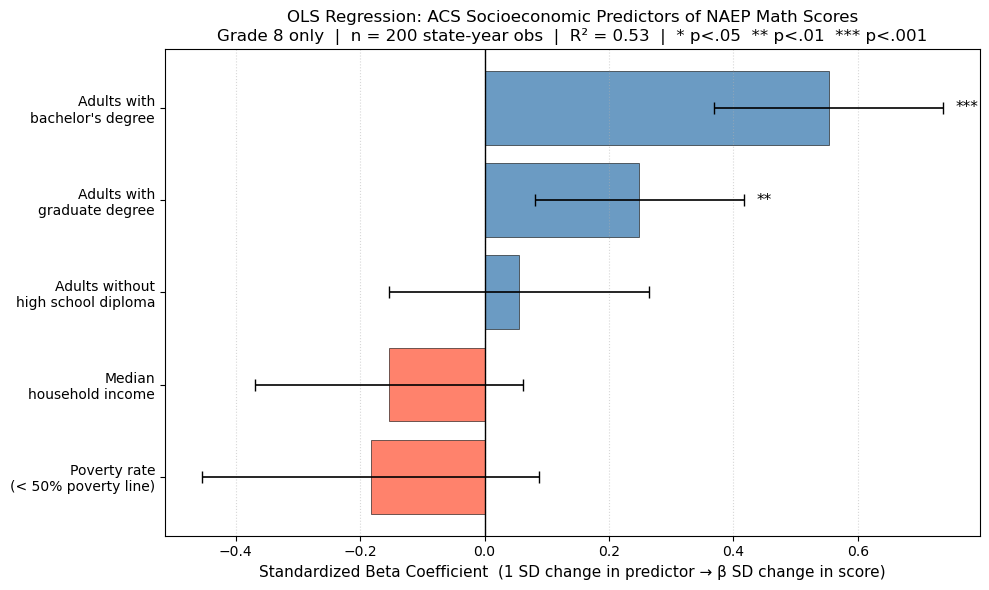


Standardized beta coefficients:
                              label      beta         pval
 Poverty rate\n(< 50% poverty line) -0.182892 1.849502e-01
           Median\nhousehold income -0.153259 1.611295e-01
Adults without\nhigh school diploma  0.055170 6.037113e-01
       Adults with\ngraduate degree  0.248728 3.880231e-03
     Adults with\nbachelor's degree  0.552779 1.334114e-08

Largest predictor: Adults with bachelor's degree (β = 0.553)
  Adults with bachelor's degree is 3.0x stronger than Poverty rate (< 50% poverty line)
  Adults with bachelor's degree is 3.6x stronger than Median household income
  Adults with bachelor's degree is 10.0x stronger than Adults without high school diploma
  Adults with bachelor's degree is 2.2x stronger than Adults with graduate degree


In [25]:
# Restrict to grade 8 — PARED is available here, and the socioeconomic signal tends
# to be stronger at grade 8 since more variance has accumulated by that point.
score_cols = [c for c in merged.columns if any(c.startswith(p) for p in
              ['gender_', 'slunch3_', 'srace10_', 'schtype_'])]

reg_df = merged[merged['grade'] == 8].copy()
reg_df['mean_score'] = reg_df[score_cols].mean(axis=1)

PREDICTORS = [
    'median_household_income',
    'pov_ratio_under_50',
    'educ_less_than_hs',
    'educ_bachelors',
    'educ_graduate',
]
PREDICTORS = [p for p in PREDICTORS if p in reg_df.columns]

# Force everything to float — pd.NA values introduced during the pivot can leave
# columns as object dtype, which statsmodels can't handle.
reg_clean = reg_df[['mean_score'] + PREDICTORS].apply(pd.to_numeric, errors='coerce').dropna()
print(f"Regression sample: {len(reg_clean)} state-year observations")

# Standardize to z-scores so all predictors are on the same scale.
# A beta of 0.5 then means: a one standard deviation increase in that predictor
# is associated with a 0.5 SD increase in NAEP scores, holding others constant.
# Without standardizing, comparing the income coefficient (in dollars) to the
# poverty rate coefficient (in percentage points) would be meaningless.
reg_std = (reg_clean - reg_clean.mean()) / reg_clean.std()

# sm.add_constant() appends a column of 1s, which gives OLS an intercept term to fit.
# Without it, the regression line would be forced through the origin.
X = sm.add_constant(reg_std[PREDICTORS])
y = reg_std['mean_score']

model = sm.OLS(y, X).fit()
print(model.summary())

coef_df = pd.DataFrame({
    'predictor': PREDICTORS,
    'beta':      model.params[PREDICTORS].values,
    'ci_low':    model.conf_int().loc[PREDICTORS, 0].values,
    'ci_high':   model.conf_int().loc[PREDICTORS, 1].values,
    'pval':      model.pvalues[PREDICTORS].values,
})

LABELS = {
    'median_household_income': 'Median\nhousehold income',
    'pov_ratio_under_50':      'Poverty rate\n(< 50% poverty line)',
    'educ_less_than_hs':       'Adults without\nhigh school diploma',
    'educ_bachelors':          "Adults with\nbachelor's degree",
    'educ_graduate':           'Adults with\ngraduate degree',
}
coef_df['label'] = coef_df['predictor'].map(LABELS)
coef_df = coef_df.sort_values('beta')

fig, ax = plt.subplots(figsize=(10, 6))

colors_bar = ['steelblue' if b > 0 else 'tomato' for b in coef_df['beta']]
ax.barh(coef_df['label'], coef_df['beta'],
        color=colors_bar, alpha=0.8, edgecolor='k', linewidth=0.5)

# Error bars show the 95% CI for each coefficient.
# Any bar whose CI crosses zero is not statistically significant at p < 0.05.
ax.errorbar(coef_df['beta'], coef_df['label'],
            xerr=[coef_df['beta'] - coef_df['ci_low'],
                  coef_df['ci_high'] - coef_df['beta']],
            fmt='none', color='black', capsize=4, linewidth=1.2)

for _, row in coef_df.iterrows():
    sig = '***' if row['pval'] < 0.001 else ('**' if row['pval'] < 0.01
          else ('*' if row['pval'] < 0.05 else ''))
    ax.text(row['ci_high'] + 0.02, row['label'], sig, va='center', fontsize=11)

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Standardized Beta Coefficient  (1 SD change in predictor → β SD change in score)',
              fontsize=11)
ax.set_title('OLS Regression: ACS Socioeconomic Predictors of NAEP Math Scores\n'
             f'Grade 8 only  |  n = {len(reg_clean)} state-year obs  |  R² = {model.rsquared:.2f}  '
             '|  * p<.05  ** p<.01  *** p<.001',
             fontsize=12)
ax.xaxis.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nStandardized beta coefficients:")
print(coef_df[['label', 'beta', 'pval']].to_string(index=False))
largest = coef_df.iloc[-1]
print(f"\nLargest predictor: {largest['label'].replace(chr(10), ' ')} (β = {largest['beta']:.3f})")
for _, row in coef_df.iterrows():
    if row['predictor'] != largest['predictor'] and row['beta'] != 0:
        ratio = abs(largest['beta'] / row['beta'])
        print(f"  {largest['label'].replace(chr(10),' ')} is {ratio:.1f}x stronger than {row['label'].replace(chr(10),' ')}")